In [1]:
import numpy as np
import pandas as pd

# Rango de x y p
xs = np.linspace(-10, 10, 200)   # 200 puntos en x
ps = np.linspace(-10, 10, 200)   # 200 puntos en p

X, P = np.meshgrid(xs, ps)
F = P*X - X**2/2

df = pd.DataFrame({
    "x": X.ravel(),
    "p": P.ravel(),
    "F": F.ravel()
})

df.to_csv("F_surface.csv", index=False)
print("Archivo generado: F_surface.csv")


Archivo generado: F_surface.csv


In [3]:
import numpy as np
import pandas as pd

# Rango
xs = np.linspace(-10, 10, 200)
ps = np.linspace(-10, 10, 200)

X, P = np.meshgrid(xs, ps)

F = P*X - X**2/2

df = pd.DataFrame({
    "x": X.ravel(),
    "p": P.ravel(),
    "F": F.ravel()
})

df.to_csv("F_surface.csv", index=False)


In [4]:
import numpy as np
import pandas as pd

Nx = 200
Ny = 200

xs = np.linspace(-10, 10, Nx)
ps = np.linspace(-10, 10, Ny)

X, P = np.meshgrid(xs, ps)
F = P*X - X**2/2

df = pd.DataFrame({
    "i": np.repeat(np.arange(Nx), Ny),
    "j": np.tile(np.arange(Ny), Nx),
    "x": X.ravel(),
    "p": P.ravel(),
    "F": F.ravel()
})

df.to_csv("F_surface_structured.csv", index=False)


In [5]:
import numpy as np
import pandas as pd

Nx = 200
Ny = 200

xs = np.linspace(-10, 10, Nx)
ps = np.linspace(-10, 10, Ny)

# Malla ordenada como ParaView quiere
X, P = np.meshgrid(xs, ps, indexing="ij")

F = P*X - X**2 / 2

df = pd.DataFrame({
    "i": np.repeat(np.arange(Nx), Ny),
    "j": np.tile(np.arange(Ny), Nx),
    "x": X.ravel(order="C"),
    "p": P.ravel(order="C"),
    "F": F.ravel(order="C")
})

df.to_csv("F_surface_structured_OK.csv", index=False)


In [6]:
import numpy as np
import pandas as pd

xs = np.linspace(-10, 10, 200)
ps = np.linspace(-10, 10, 200)

X, P = np.meshgrid(xs, ps)

F = P*X - X**2/2

df = pd.DataFrame({
    "x": X.ravel(),
    "p": P.ravel(),
    "F": F.ravel()
})

df.to_csv("F_surface_OK.csv", index=False)


In [7]:
#### ParaView Python script ####
from paraview.simple import *
import numpy as np

# Generate structured grid
Nx = 200
Ny = 200

xs = np.linspace(-10, 10, Nx)
ps = np.linspace(-10, 10, Ny)

X, P = np.meshgrid(xs, ps)
F = P*X - X**2/2

# Create Programmable Source
src = ProgrammableSource()
src.OutputDataSetType = 'vtkStructuredGrid'
src.Script = f"""
import numpy as np
from vtkmodules.vtkCommonDataModel import vtkStructuredGrid
from vtkmodules.vtkCommonCore import vtkPoints, vtkDoubleArray

Nx = {Nx}
Ny = {Ny}

xs = np.linspace(-10, 10, Nx)
ps = np.linspace(-10, 10, Ny)
X, P = np.meshgrid(xs, ps)
F = P*X - X**2/2

output.SetExtent(0, Nx-1, 0, Ny-1, 0, 0)

pts = vtkPoints()
pts.SetNumberOfPoints(Nx*Ny)
k = 0
for j in range(Ny):
    for i in range(Nx):
        pts.SetPoint(k, float(X[j,i]), float(P[j,i]), float(F[j,i]))
        k += 1

output.SetPoints(pts)

arr = vtkDoubleArray()
arr.SetName("F")
arr.SetNumberOfValues(Nx*Ny)
for j in range(Ny):
    for i in range(Nx):
        arr.SetValue(j*Nx + i, float(F[j,i]))

output.GetPointData().AddArray(arr)
"""

# Show
View = GetActiveViewOrCreate('RenderView')
srcDisplay = Show(src, View)

ColorBy(srcDisplay, ('POINTS', 'F'))
srcDisplay.SetRepresentationType('Surface')
srcDisplay.RescaleTransferFunctionToDataRange(True)

Render()


ModuleNotFoundError: No module named 'paraview'

In [8]:
import numpy as np
import plotly.graph_objects as go

xs = np.linspace(-10, 10, 300)
ps = np.linspace(-10, 10, 300)

X, P = np.meshgrid(xs, ps)
F = P*X - X**2/2

fig = go.Figure(data=[
    go.Surface(
        x=X, 
        y=P, 
        z=F, 
        colorscale='Inferno', 
        showscale=True
    )
])

fig.update_layout(
    title='Superficie F(x,p)=px - x^2/2',
    scene=dict(
        xaxis_title='x',
        yaxis_title='p',
        zaxis_title='F',
        aspectmode='cube'
    )
)

fig.show()


In [9]:
import numpy as np
import plotly.graph_objects as go

# ====== 1. Datos ======
xs = np.linspace(-10, 10, 300)
ps = np.linspace(-10, 10, 300)

X, P = np.meshgrid(xs, ps)
F = P*X - X**2/2

# ====== 2. Superficie ======
fig = go.Figure(data=[
    go.Surface(
        x=X,
        y=P,
        z=F,
        colorscale="Inferno",
        showscale=True,
        colorbar=dict(
            title="F(x,p)",
            titleside="right",
            ticks="outside"
        )
    )
])

# ====== 3. Estética / layout ======
fig.update_layout(
    title=dict(
        text="Superficie  F(x,p) = p·x - x²/2",
        x=0.5,              # centrar título
        xanchor="center",
        font=dict(size=22)
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, t=60, b=0),
    template="plotly_white",
    scene=dict(
        xaxis=dict(
            title="x",
            titlefont=dict(size=18),
            tickfont=dict(size=12),
            showbackground=True,
            backgroundcolor="rgba(200,200,255,0.15)",
            gridcolor="lightgrey"
        ),
        yaxis=dict(
            title="p",
            titlefont=dict(size=18),
            tickfont=dict(size=12),
            showbackground=True,
            backgroundcolor="rgba(200,255,200,0.15)",
            gridcolor="lightgrey"
        ),
        zaxis=dict(
            title="F",
            titlefont=dict(size=18),
            tickfont=dict(size=12),
            showbackground=True,
            backgroundcolor="rgba(255,200,200,0.15)",
            gridcolor="lightgrey"
        ),
        # Proporción de los ejes
        aspectmode="manual",
        aspectratio=dict(x=1.2, y=1.2, z=0.8),
        # Cámara (ángulo de vista)
        camera=dict(
            eye=dict(x=1.7, y=1.6, z=0.8)
        )
    )
)

fig.show()


ValueError: Invalid property specified for object of type plotly.graph_objs.surface.ColorBar: 'titleside'

Did you mean "title"?

    Valid properties:
        bgcolor
            Sets the color of padded area.
        bordercolor
            Sets the axis line color.
        borderwidth
            Sets the width (in px) or the border enclosing this
            color bar.
        dtick
            Sets the step in-between ticks on this axis. Use with
            `tick0`. Must be a positive number, or special strings
            available to "log" and "date" axes. If the axis `type`
            is "log", then ticks are set every 10^(n*dtick) where n
            is the tick number. For example, to set a tick mark at
            1, 10, 100, 1000, ... set dtick to 1. To set tick marks
            at 1, 100, 10000, ... set dtick to 2. To set tick marks
            at 1, 5, 25, 125, 625, 3125, ... set dtick to
            log_10(5), or 0.69897000433. "log" has several special
            va

Figura guardada como: F_quadratic_infinite_grid.png


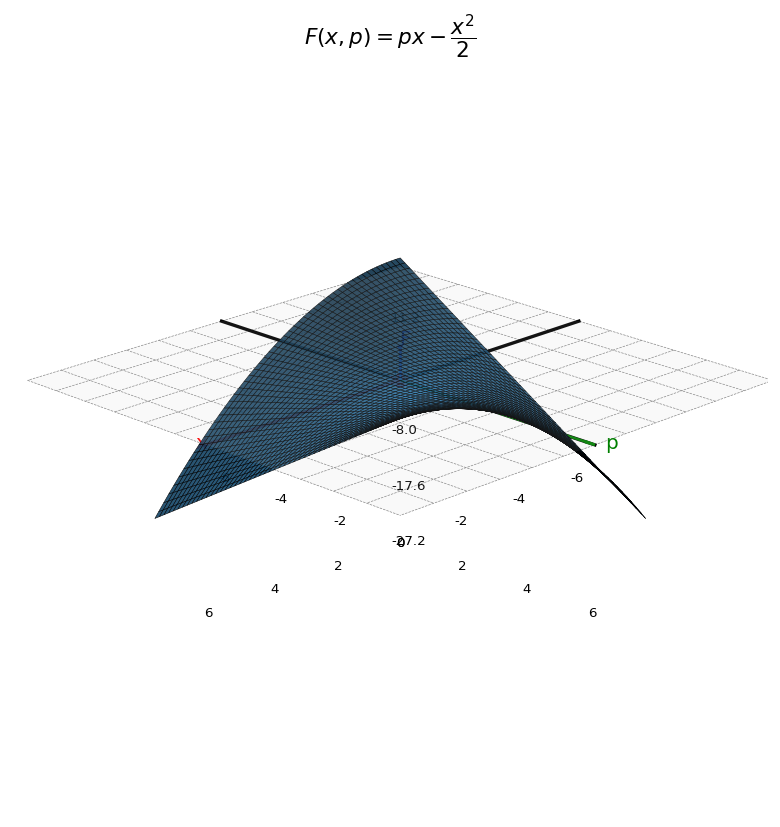

Figura guardada como: F_cubic_infinite_grid.png


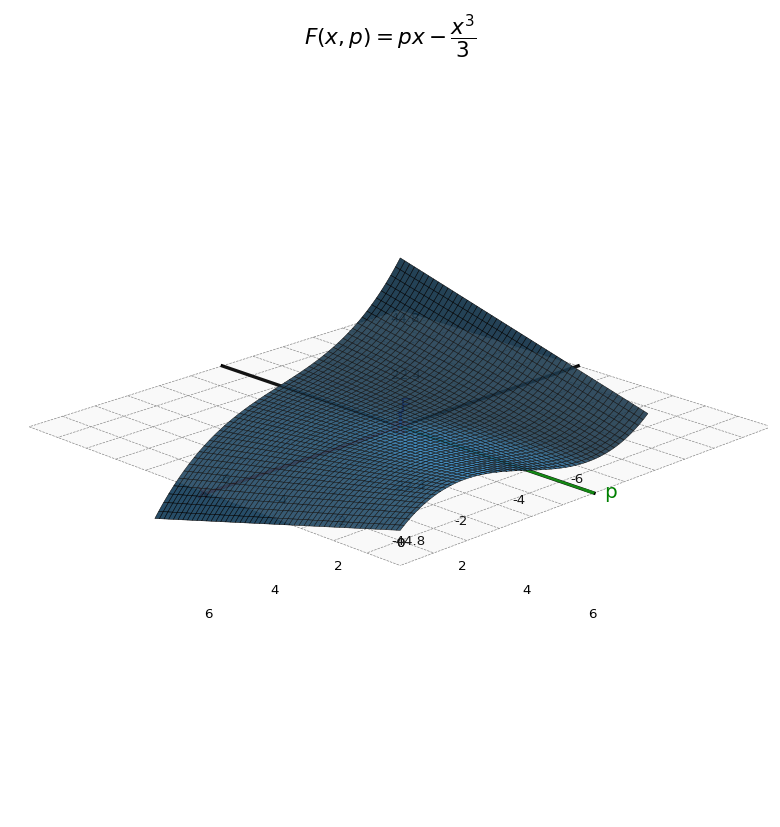

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Funciones F(x,p)
# =======================

def F_quad(x, p):
    return p * x - x**2 / 2.0

def F_cubic(x, p):
    return p * x - x**3 / 3.0

# =======================
#  Función genérica para graficar
# =======================

def plot_F_surface(F_func, titulo, fname,
                   L_floor=6, x_range=(-4, 4), p_range=(-4, 4),
                   z_range=None):

    # Mallado
    x = np.linspace(*x_range, 200)
    p = np.linspace(*p_range, 200)
    X, P = np.meshgrid(x, p)
    Z = F_func(X, P)

    if z_range is None:
        zmin, zmax = Z.min(), Z.max()
        margen = 0.1 * (zmax - zmin)
        z_range = (zmin - margen, zmax + margen)

    fig = plt.figure(figsize=(7, 7), dpi=120)
    ax = fig.add_subplot(111, projection='3d')

    # ----- Superficie -----
    ax.plot_surface(X, P, Z,
                    rstride=4, cstride=4,
                    linewidth=0.3, edgecolor='k',
                    alpha=0.9, color="#1f77b4")

    # =======================
    #  Piso tipo "infinite grid"
    # =======================
    L = L_floor
    grid = np.linspace(-L, L, 13)

    for pp in grid:
        ax.plot([-L, L], [pp, pp], [0, 0],
                linestyle='--', linewidth=0.4, color='0.5')
    for xx in grid:
        ax.plot([xx, xx], [-L, L], [0, 0],
                linestyle='--', linewidth=0.4, color='0.5')

    PX, PY = np.meshgrid(grid, grid)
    PZ = np.zeros_like(PX)
    ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False, color='0.8')

    # ====== LÍNEAS X=0 E P=0 EN EL PISO ======
    ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
    ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

    # =======================
    #  Ejes con flechas
    # =======================
    axis_len = L
    ax.quiver(0, 0, 0, axis_len, 0, 0,
              arrow_length_ratio=0.05, color='r')
    ax.quiver(0, 0, 0, 0, axis_len, 0,
              arrow_length_ratio=0.05, color='g')
    ax.quiver(0, 0, 0, 0, 0, axis_len,
              arrow_length_ratio=0.05, color='b')

    ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12, color='r')
    ax.text(0, axis_len*1.05, 0, 'p', fontsize=12, color='g')
    ax.text(0, 0, axis_len*1.05, 'F', fontsize=12, color='b')

    # =======================
    #  Marcar el origen
    # =======================
    ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
    d = 0.3
    ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
    ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
    ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

    # =======================
    #  Estilo
    # =======================
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_zlim(*z_range)
    ax.set_box_aspect((1, 1, 0.45))

    # Ocultamos ticks "reales"
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.grid(False)
    ax.xaxis.line.set_linewidth(0)
    ax.yaxis.line.set_linewidth(0)
    ax.zaxis.line.set_linewidth(0)

    ax.xaxis.pane.set_alpha(0)
    ax.yaxis.pane.set_alpha(0)
    ax.zaxis.pane.set_alpha(0)

    # Números manuales sobre el piso
    ticks = np.arange(-6, 7, 2)
    for t in ticks:
        ax.text(t, 0, z_range[0] + 0.1, f"{t}",
                ha='center', va='top', fontsize=8)
    for t in ticks:
        ax.text(0, t, z_range[0] + 0.1, f"{t}",
                ha='center', va='top', fontsize=8)

    for t in np.linspace(z_range[0], z_range[1], 5):
        ax.text(0.3, 0, t, f"{t:.1f}",
                ha='left', va='center', fontsize=8)

    ax.view_init(elev=20, azim=45)
    ax.set_title(titulo, fontsize=13)

    plt.tight_layout()
    fig.savefig(fname, dpi=600, bbox_inches="tight")
    print(f"Figura guardada como: {fname}")
    plt.show()

# =======================
#  Llamadas concretas
# =======================

plot_F_surface(
    F_func=F_quad,
    titulo=r"$F(x,p)=px-\dfrac{x^{2}}{2}$",
    fname="F_quadratic_infinite_grid.png"
)

plot_F_surface(
    F_func=F_cubic,
    titulo=r"$F(x,p)=px-\dfrac{x^{3}}{3}$",
    fname="F_cubic_infinite_grid.png"
)


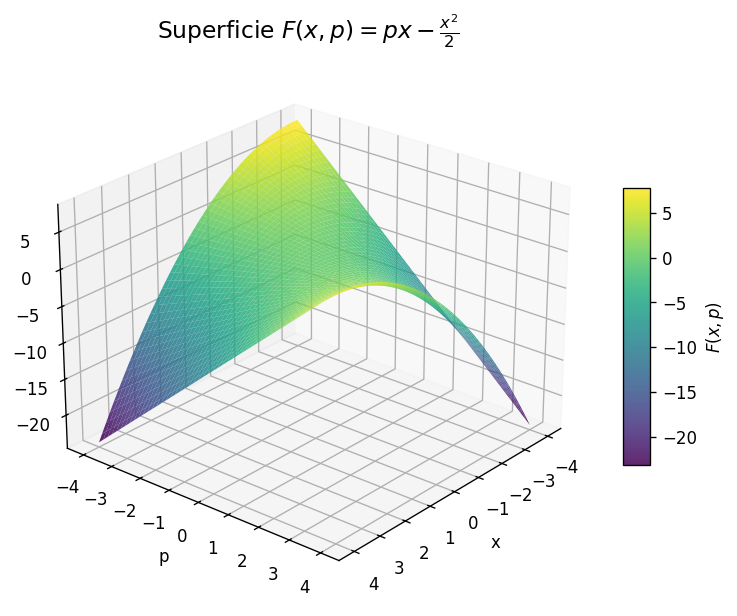

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ================================
#  Definir la función F(x,p)
# ================================
def F(x, p):
    return p*x - x**2/2

# Rango
x = np.linspace(-4, 4, 200)
p = np.linspace(-4, 4, 200)
X, P = np.meshgrid(x, p)
Z = F(X, P)

# ================================
#  Gráfica 3D limpia y profesional
# ================================
fig = plt.figure(figsize=(8, 6), dpi=120)
ax = fig.add_subplot(111, projection='3d')

# Superficie
surf = ax.plot_surface(
    X, P, Z, cmap='viridis', alpha=0.85,
    linewidth=0, antialiased=True
)

# Barra de color
fig.colorbar(surf, shrink=0.5, aspect=10, label=r"$F(x,p)$")

# Etiquetas
ax.set_xlabel("x")
ax.set_ylabel("p")
ax.set_zlabel(r"$F(x,p)$")

ax.set_title(r"Superficie $F(x,p)=px-\frac{x^{2}}{2}$", fontsize=14)

# Vista estándar — oblicua clara
ax.view_init(elev=25, azim=40)

# Guardar alta resolución
plt.savefig("F_surface_quadratic_clean.png", dpi=600, bbox_inches="tight")
plt.show()


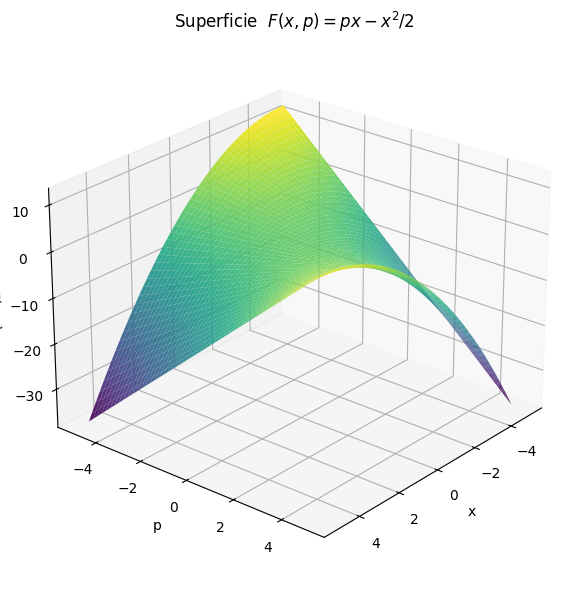

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Rango de variables
x = np.linspace(-5, 5, 200)
p = np.linspace(-5, 5, 200)
X, P = np.meshgrid(x, p)

# Función
F = P*X - X**2/2

# Figura
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Superficie limpia y clara
ax.plot_surface(X, P, F,
                cmap="viridis",
                edgecolor='none',
                alpha=0.9)

# Etiquetas
ax.set_xlabel("x")
ax.set_ylabel("p")
ax.set_zlabel("F(x,p)")
ax.set_title("Superficie  $F(x,p)=px - x^{2}/2$")

# Vista similar a GeoGebra
ax.view_init(elev=25, azim=40)

plt.tight_layout()
plt.show()


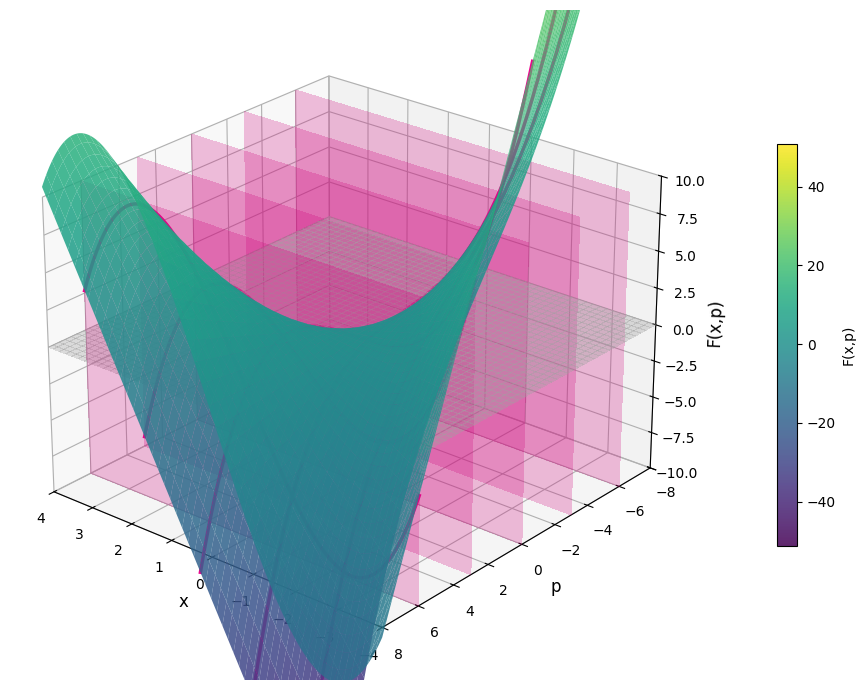

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # importa el proyector 3D

# ==========================
# 1. Dominio y superficie
# ==========================
xmin, xmax = -4, 4
pmin, pmax = -8, 8

nx, np_points = 200, 200  # malla fina para buena calidad

x = np.linspace(xmin, xmax, nx)
p = np.linspace(pmin, pmax, np_points)

X, P = np.meshgrid(x, p)
F = P*X - X**3 / 3.0

# ==========================
# 2. Figura 3D
# ==========================
fig = plt.figure(figsize=(10, 7))  # tamaño físico de la figura
ax = fig.add_subplot(111, projection='3d')

# --- Superficie F(x,p) ---
surf = ax.plot_surface(
    X, P, F,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.85
)

# --- Plano F = 0 (gris) ---
X0, P0 = np.meshgrid(x, p)
Z0 = np.zeros_like(X0)
ax.plot_surface(
    X0, P0, Z0,
    color="lightgray",
    alpha=0.35,
    linewidth=0,
    antialiased=False
)

# ==========================
# 3. Planos p = p0 y curvas F_{p0}(x)
# ==========================
p_slices = [-6, -3, 0, 3, 6]   # cambia/añade valores si quieres

zmin, zmax = -10, 10

for p0 in p_slices:
    # Plano vertical p = p0
    Xpl, Zpl = np.meshgrid(
        np.linspace(xmin, xmax, 2),
        np.linspace(zmin, zmax, 2)
    )
    Ppl = np.full_like(Xpl, p0)

    ax.plot_surface(
        Xpl, Ppl, Zpl,
        color="#ec068d",   # Hollywood Cerise aprox
        alpha=0.25,
        linewidth=0,
        antialiased=False
    )

    # Curva de intersección F_{p0}(x) = p0 x - x^3/3
    x_line = np.linspace(xmin, xmax, 400)
    F_line = p0 * x_line - x_line**3 / 3.0
    ax.plot(
        x_line,
        np.full_like(x_line, p0),
        F_line,
        color="#ec068d",
        linewidth=2.5
    )

# ==========================
# 4. Estética de ejes
# ==========================
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("p", fontsize=12)
ax.set_zlabel("F(x,p)", fontsize=12)

ax.set_xlim(xmin, xmax)
ax.set_ylim(pmin, pmax)
ax.set_zlim(zmin, zmax)

# Ángulo de vista parecido al que te gusta
ax.view_init(elev=25, azim=130)

# Barra de color opcional
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="F(x,p)")

plt.tight_layout()

# ==========================
# 5. Guardar en alta resolución
# ==========================
plt.savefig("F_cubica_superficie_slices.png", dpi=400, bbox_inches="tight")
plt.show()


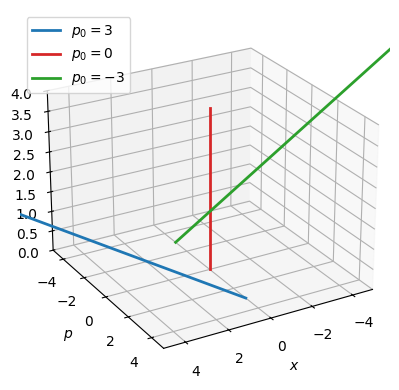

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # importa el proy. 3D

# ----------------------
# Parámetros del sistema
# ----------------------
m = 1.0      # masa
x0 = 0.0     # posición inicial
t_min = 0.0
t_max = 4.0
n_points = 200

t = np.linspace(t_min, t_max, n_points)

# Valores de p0 que queremos graficar
p0_values = [3.0, 0.0, -3.0]
colors = ["tab:blue", "tab:red", "tab:green"]
labels = [r"$p_{0}=3$", r"$p_{0}=0$", r"$p_{0}=-3$"]

# ----------------------
# Figura 3D
# ----------------------
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection="3d")

for p0, c, lab in zip(p0_values, colors, labels):
    # Soluciones:
    # x(t) = x0 + (p0/m) t
    x = x0 + (p0 / m) * t
    p = p0 * np.ones_like(t)

    ax.plot(x, p, t, color=c, linewidth=2, label=lab)

# ----------------------
# Estética del gráfico
# ----------------------
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$p$")
ax.set_zlabel(r"$t$")

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(0, 4)

# Ángulo de vista (ajústalo a tu gusto)
ax.view_init(elev=25, azim=60)

ax.legend(loc="upper left")

plt.tight_layout()

# Guardar figura para LaTeX
plt.savefig("fase_extendida_libre.png", dpi=300, bbox_inches="tight")
plt.show()


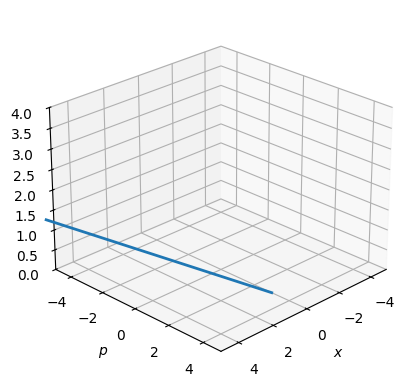

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario para 3D

m = 1.0
x0 = 0.0
p0 = 3.0

t = np.linspace(0.0, 4.0, 200)

x = x0 + (p0/m)*t      # x(t) = x0 + (p0/m) t
p = p0 * np.ones_like(t)  # p(t) = p0
# t = t

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x, p, t, linewidth=2)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$p$")
ax.set_zlabel(r"$t$")

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(0, 4)

ax.view_init(elev=25, azim=45)  # solo cambia el ángulo de cámara

plt.tight_layout()
plt.show()


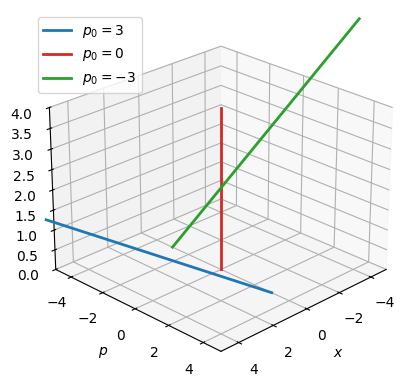

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

m = 1.0
x0 = 0.0

t = np.linspace(0.0, 4.0, 200)

p0_values = [3.0, 0.0, -3.0]
colors    = ["tab:blue", "tab:red", "tab:green"]
labels    = [r"$p_{0}=3$", r"$p_{0}=0$", r"$p_{0}=-3$"]

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")

for p0, c, lab in zip(p0_values, colors, labels):
    x = x0 + (p0/m)*t      # x(t)
    p = p0 * np.ones_like(t)  # p(t)

    ax.plot(x, p, t, color=c, linewidth=2, label=lab)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$p$")
ax.set_zlabel(r"$t$")

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(0, 4)

ax.view_init(elev=25, azim=45)

ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("fase_extendida_libre.png", dpi=300, bbox_inches="tight")
plt.show()
